Hello! This is a system for automatically testing statistical hypotheses **AutoStatFlow!** 25-26'

I implemented this project with the support of my mentor (reviewer) Edward :)

>All code, logic, and documentation were written by me, Dmitry Baranov (Russia, 15 years old, 9th grade)

***
Привет! Это система для автоматической проверки статистических гипотез **AutoStatFlow!** 25-26'

Данный проект я реализовывал при поддержке моего наставника (ревьювера) Эдварда :)

>Весь код, логика, и документации написанны мной, Барановым Дмитрием (Россия, 15 лет, 9 класс)

## Code of System
***
Код системы

### **imports**
Installing libraries
---
***
Установка библиотек

In [7]:
from IPython.display import clear_output

!pip3 install langgraph
!pip3 install -U langchain-groq

clear_output(wait=False)

In [8]:
from typing import TypedDict, List, Annotated, Literal
from langgraph.graph.message import add_messages
from pandas.api.types import is_numeric_dtype

from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import SystemMessage
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from pydantic import BaseModel, Field

import pandas as pd
import json

import matplotlib.pyplot as plt
import seaborn as sns
import io
import PIL.Image
from scipy.stats import probplot
from scipy.stats import shapiro
import google.generativeai as genai

### Initialization LLM
Инициализация большой языковой модели

In [ ]:
llm = ChatGroq(
    model='llama-3.3-70b-versatile'
    , temperature=0.1
    , api_key='' # Need API
)

genai.configure(api_key='') # Need API

### State of Graph
***
Состояние графа

In [10]:
class UserState(TypedDict):
    messages: Annotated[list, add_messages] # - conversation history
    # - диалог
    data: pd.DataFrame                      # - dataset
    # - датасет

    target: str                             # - target variable
    # - целевая переменная
    grouping_variable: str                  # - grouping variable
    # - группирующая переменная
    grouping_values: List[str]              # - grouping variable values
    # - значения групповой переменной
    satisfied: str                          # - state of selected variables
    # - состояние выбронных переменных
    is_normal_target: bool                  # - whether the target distribution is normal
    # - нормальное ли распределен таргет

    samples: List[str]                      # - groups for the statistical test
    # - группы для стат теста

    target_dtype: str                       # - target variable data type
    # - тип целевой переменной
    grouping_variable_dtype: str            # - grouping variable data type
    # - тип группирующей переменной

    method_of_var_analisis: str             # - variance analysis method
    # - метод дисперсионного анализа**

    artefacts: List[str]                    # - artifacts to be passed to the LLM for summary generation
    # - артефакты, все что будет переданно в llm для вывода сводки

    summary: str                            # - research summary
    # - сводка исследования

### Definition of main variables
***
Определение главных переменные

In [11]:
class TargetExtraction(BaseModel):
    target: str = Field(description='Название зависимой переменной. По которой будет производиться стат тест. Тип может быть любой.')
    grouping_variable: str = Field(description='Группирующая переменная. Если подразумеватеся проверка нескольких групп, рекомендуется использовать одну переменную. Тип может быть любой.')
    grouping_values: List[str] = Field(description='Значения, разделюящие группирующую переменную на выборки (в том числе и какие-то значение числовой переменной, НО передавать строго списком, из str значений). Также тут можем быть СПИСОК с одним значением "ALL", если к примеру, необходимо провести анализ взаимосвязи двх количественных переменных.')

def find_variables(state: UserState) -> UserState:
    data = state['data']
    all_counts = {}
    for col in data.columns:
        counts = data[col].value_counts().head(10).to_dict()
        if len(data[col].unique()) > 10:
            counts['...'] = f'and {len(data[col].unique()) - 10} more'

        all_counts[col] = counts
    sys_prompt = f'Ты помощник аналитика. По сообщению пользователя, тебе необходимо определить значения зависимой переменной и группирующей. Исходи из того, что хочет пользователь.'\
                f'Вот данные, пользователя. dtypes: {data.dtypes.to_string()}\nvalues counts: {json.dumps(all_counts, ensure_ascii=False, indent=2)}'

    messages = state['messages']
    instruction = HumanMessage(content='Внимательно изучи последние системные сообщения об ошибках и исправь свой выбор переменных согласно им. Не повторяй предыдущие ошибки.')
    structured_llm = llm.with_structured_output(TargetExtraction)

    result = structured_llm.invoke([sys_prompt] + messages + [instruction])

    return {
        'target': result.target
        , 'grouping_variable': result.grouping_variable
        , 'grouping_values': result.grouping_values
    }

In [12]:
class CorrectingVariables(BaseModel):
    answer: Literal['YES', 'NO'] = Field(description='Выбор удовлетворил пользователя? Толко YES или NO')
    correction_message: str = Field(description='Опиши переменные которые пользователь хочет поменять и на что, а какие хочет оставить. Если пользователя все устроило, оставь пробел.')

def is_correct_variables(state: UserState) -> UserState:
    print(f'Выбран таргет: {state['target']}, групповая переменная: {state['grouping_variable']}, ее значения: {' '.join(state['grouping_values'])}')
    response = input('Вас удовлетворяет выбор? ')
    structured_llm = llm.with_structured_output(CorrectingVariables)
    analysis = structured_llm.invoke(
        f'Пользователь ответил на выбор переменных. \n'
        f'Выбрано: target={state['target']}, group={state['grouping_variable']}. \n'
        f'Ответ пользователя: {response}'
    )
    new_messages = state.get('messages', [])
    if analysis.answer == 'NO':
        feedback_msg = SystemMessage(content=f"ОШИБКА: Пользователь недоволен. Исправь выбор. {analysis.correction_message}")
        new_messages.append(feedback_msg)
    return {
        'satisfied': analysis.answer,
        'messages': new_messages
    }

### Preprocessing with mini LLM-agent
***
Предобработка с LLM агентом

In [13]:
def process_dtypes_strictly(state: UserState) -> UserState:
    data = state['data'].copy()
    t_col = state['target']
    g_col = state['grouping_variable']

    artefact = f''

    try:
        if (np.sort(data[t_col].unique().astype(int)) == np.array([0, 1])).all():
            data[t_col] = data[t_col].astype('str')
            artefact += f'У {t_col}, был изменен тип данных на string. -> бинарная переменная'
    except:
        ...
    try:
        if (np.sort(data[g_col].unique().astype(int)) == np.array([0, 1])).all():
            data[g_col] = data[g_col].astype('str')
            artefact += f'У {g_col}, был изменен тип данных на string. -> бинарная переменная'
    except:
        ...
    return {'data': data
            , 'target_dtype': str(data[t_col].dtype)
            , 'grouping_variable_dtype': str(data[g_col].dtype)
            , 'artefacts': state.get('artefacts', []) + [artefact]}

In [14]:
import ast
from typing import Optional

def change_dtype(data: pd.DataFrame, change_dtype_column: str, change_column_dtype: str) -> pd.DataFrame:
    try:
        print('CHANGE DTYPE!')
        data[change_dtype_column] = data[change_dtype_column].astype(change_column_dtype)
    except:
        print('some thing went wrong! -CNG')
    return data

def make_buckets(data: pd.DataFrame, buckets_column: str, buckets_str: Optional[str]) -> pd.DataFrame:
    if not buckets_str:
        return data
    try:
        buckets = ast.literal_eval(buckets_str.strip())
        if not isinstance(buckets, list):
            print(f'Ожидался список, пришло: {type(buckets)}')
            return data
        labels = [f'{buckets[i]}-{buckets[i+1]}' for i in range(len(buckets)-1)]
        data[buckets_column] = pd.cut(
            data[buckets_column],
            bins=buckets,
            labels=labels,
            include_lowest=True
        )
    except (ValueError, SyntaxError) as e:
        print(f'Ошибка парсинга интервалов "{buckets_str}": {e}')
    except Exception as e:
        print(f'Непредвиденная ошибка: {e}')
    return data

def make_groupby_and_agg(data: pd.DataFrame, grouping_by: str, agg_what: str, agg_func: str) -> str:
    try:
        cnt_data = data.copy()
        if agg_func in ['mean', 'sum', 'median']:
            cnt_data[agg_what] = pd.to_numeric(cnt_data[agg_what], errors='coerce')
        res = cnt_data.groupby(grouping_by, observed=True)[agg_what].agg(agg_func).reset_index()
        info_to_artefacts = str(res)
    except Exception as e:
        print(f'Something went wrong! -AGG: {e}')
        info_to_artefacts = 'ошибка в агрегации данных (Не имеет критических значений - все в норме).'
    return info_to_artefacts

In [15]:
from typing import Literal, Optional
from typing import Optional, Literal
from pydantic import BaseModel, Field

class PreprocessingExtraction(BaseModel):
    make_buckets: bool = Field(
        description='REQUIRED: Use JSON boolean true/false. True если нужно разбить на интервалы.'
    )
    buckets_column: Optional[str] = Field(
        default=None,
        description='Название колонки для интервалов.'
    )
    buckets: Optional[str] = Field(
        default=None,
        description='Интервалы списком, например: "[0, 10, 20]". Нельзя использовать знаки ("-") исключительно, крайние точки интервалов!"'
    )

    change_dtype: bool = Field(
        description='REQUIRED: Use JSON boolean true/false. True если нужно сменить тип данных.'
    )
    change_dtype_column: Optional[str] = Field(
        default=None,
        description='Название колонки для смены типа.'
    )
    change_column_dtype: Optional[Literal['int', 'float', 'datetime', 'str']] = Field(
        default=None,
        description='Целевой тип данных.'
    )
    make_groupby_and_agg: bool = Field(
        description='REQUIRED: Use JSON boolean true/false. True если нужно сгруппировать данные и после сагрегировать'
    )
    grouping_by: Optional[str] = Field(
        default=None,
        description='Название колонки для группировки данных'
    )
    agg_what: Optional[str] = Field(
        default=None,
        description='Название колонки (после группировки) для агрегации данных'
    )
    agg_func: Optional[str] = Field(
        default=None,
        description='Функция, для агрегации (mean, min, max)'
    )

def make_preprocessing(state: UserState) -> UserState:
    data = state['data']

    target = state['target']
    grouping_variable = state['grouping_variable']
    grouping_values = state['grouping_values']

    all_counts = {}
    for col in data.columns:
        counts = data[col].value_counts().head(10).to_dict()
        if len(data[col].unique()) > 10:
            counts['...'] = f'and {len(data[col].unique()) - 10} more'

        all_counts[col] = counts

    sys_prompt = f'Определи, какой тип предобработки требуется для данных.\n'\
                 f'head: {data.head()}\n describe: {data.describe()}\n value-counts: {json.dumps(all_counts, ensure_ascii=False, indent=2)}'\
                 f'Согласованные с пользователем таргет: {target}, группирующая переменная: {grouping_variable}, ее значения: {grouping_values}'\
                 f'Так, смена типа данных необходима если того требует пользователь, либо она сильно ограниченна, к примеру, всего два-три уникальных значения.'\
                 f'Реализация бакетов, может пригодиться, если в данных нету тех переменных, которые были согласованны с пользоватлем!'\
                 f'Также есть функция агрегации, она поможет сделать некие выводы, однако исходные данные она не меняет!'
    messages = state['messages']
    instruction = HumanMessage(content='Внимательно изучи диалог, и ответь на вопрос.')
    structured_llm = llm.with_structured_output(PreprocessingExtraction)

    result = structured_llm.invoke([sys_prompt] + messages + [instruction])

    artefacts = f''

    if result.change_dtype:
        print('Меняю тип данных!')
        data = change_dtype(data, result.change_dtype_column, result.change_column_dtype)
        artefacts += f'Был сменен тип данных у {result.change_dtype_column}, на {result.change_column_dtype}'
    if result.make_buckets:
        print('Реализовываю интервалы!')
        data = make_buckets(data, result.buckets_column, result.buckets)
        artefacts += f'Были реализованны интервалы для переменной {result.buckets_column}, {result.buckets}'
    if result.make_groupby_and_agg:
        print('Делаю агрегацию!')
        info = make_groupby_and_agg(data, result.grouping_by, result.agg_what, result.agg_func)
        artefacts += f'Была реализованна группировка данных по {result.grouping_by} для переменной {result.agg_what}, с функцией {result.agg_func}. Результат: {info}. Далее работа по НЕ Агрегированным данным!'

    return {'data': data
            , 'artefacts': state.get('artefacts', []) + [artefacts]}

### Cleaning data
***
Очистка данных

In [16]:
def cleaning_target(state: UserState) -> UserState:
    data = state['data']
    target = state['target']
    grouping_variable = state['grouping_variable']

    lower_bound = None
    upper_bound = None

    if data[target].dtype in ['float64', 'int64']:
        q1 = data[target].quantile(0.25)
        q3 = data[target].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        data = data[(data[target] >= lower_bound) & (data[target] <= upper_bound)]

    if lower_bound is not None:
        count_removed = len(state['data']) - len(data)
        artefact = f'Были очищены выбросы: {count_removed}. Границы: {lower_bound:.2f} - {upper_bound:.2f}'
    else:
        artefact = f'Переменная {target} не является числовой, очистка выбросов пропущена.'

    if data[grouping_variable].dtype in ['float64', 'int64']:
        q1 = data[grouping_variable].quantile(0.25)
        q3 = data[grouping_variable].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        data = data[(data[grouping_variable] >= lower_bound) & (data[grouping_variable] <= upper_bound)]

    if lower_bound is not None:
        count_removed = len(state['data']) - len(data)
        artefact += f'Были очищены выбросы: {count_removed}. Границы: {lower_bound:.2f} - {upper_bound:.2f}'
    else:
        artefact += f'Переменная {grouping_variable} не является числовой, очистка выбросов пропущена.'

    return {
        'data': data,
        'artefacts': state.get('artefacts', []) + [artefact]
    }


### Node for transition to stat tests
***
Узел перехода к стат тестам

In [17]:
def identifying_variables(state: UserState) -> UserState:
    # target & grouping_variable
    data = state['data']
    groups = state['grouping_values']

    target = state['target']
    grouping_variable = state['grouping_variable']

    len_of_groups = len(groups)
    if len_of_groups == 1 or len_of_groups == 2:
        if is_numeric_dtype(data[target]) and is_numeric_dtype(data[grouping_variable]):
            if groups[0] == 'ALL':
                print(f'две количественные!')
                return 'ALL_NUMERIC' # две количественные
            else:
                print(f'одна номинативная друга количественная!')
                return 'ONE_NUMERIC_AND_ONE_NOMINATIV' # одна номинативная друга количественная
        elif not is_numeric_dtype(data[target]) and not is_numeric_dtype(data[grouping_variable]):
            print(f'обе номинативные!')
            return 'ALL_NOMINATIV' # обе номинативные
        elif is_numeric_dtype(data[target]) and not is_numeric_dtype(data[grouping_variable]):
            print(f'одна номинативная друга количественная')
            return 'ONE_NUMERIC_AND_ONE_NOMINATIV' # одна номинативная друга количественная
    else:
        if is_numeric_dtype(data[target]):
            print(f'таргет количественный!')
            return 'MANY_GROUPS_AND_NUMERIC_TARGET' # таргет количественный
        elif not is_numeric_dtype(data[target]):
            print(f'таргет номинативный!')
            return 'MANY_GROUPS_AND_NOMINATIV_TARGET' # таргет номинативный

### Both variables are numeric
***
Обе переменные количественные

In [18]:
# identifying_variables -> ALL_NUMERIC
import statsmodels.api as sm
from scipy.stats import pearsonr
from scipy.stats import spearmanr

def make_lin_reg(state: UserState) -> UserState:
    data = state['data']
    x = sm.add_constant(data[state['grouping_variable']])
    y = data[state['target']]
    model = sm.OLS(y, x).fit()
    artefact = f'По скольку в выбранных переменных обе переменные количественные, построим линейную регрессию. Сводка (summary):\n{str(model.summary())}'
    print('Уже строю линейную регрессию!')
    return {'artefacts': state.get('artefacts', []) + [artefact]}

def make_corrs(state: UserState) -> UserState:
    data = state['data']
    pr_stat, _ = pearsonr(data[state['target']], data[state['grouping_variable']])
    sp_stat, _ = spearmanr(data[state['target']], data[state['grouping_variable']])
    artefact = f'Построим корреляции между признаками, pearson: {pr_stat}, spearman: {sp_stat}'
    return {'artefacts': state.get('artefacts', []) + [artefact]}

### Both variables are nominative
***
Обе переменные номинативные

In [19]:
# identifying_variables -> ALL_NOMINATIV
from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact

def make_chi2(state: UserState) -> UserState:
    data = state['data']
    target = state['target']
    grouping_variable = state['grouping_variable']
    contingency_table = pd.crosstab(data[target], data[grouping_variable])
    res = chi2_contingency(contingency_table)
    print('Уже проверию Хи квадратом Пирсона!')
    artefact = f'Был проведен анализ таблицы сопряженности, вот таблица: {contingency_table}, вот результат (Хи-квадрат): {res}'
    return {'artefacts': state.get('artefacts', []) + [artefact]}

def make_fisher_exact(state: UserState) -> UserState:
    data = state['data']
    target = state['target']
    grouping_variable = state['grouping_variable']
    contingency_table = pd.crosstab(data[target], data[grouping_variable])
    res = fisher_exact(contingency_table)
    artefact = f'Также был проведен точный критерий фишера: {res}'
    return {'artefacts': state.get('artefacts', []) + [artefact]}

### One variable is quantitative, the second is nominative
***
Одна переменная количественная, вторая номинативная

In [20]:
# identifying_variables -> ONE_NUMERIC_AND_ONE_NOMINATIV
class IsNormal(BaseModel):
    is_norm: bool = Field(description='Ответ True или False, распределение признака схоже с нормальным?')
    justification: str = Field(description='Очень короткое обоснование ответа (50 слов максимум)')

vision_llm = genai.GenerativeModel(
    model_name='gemini-flash-latest',
    generation_config={
        'response_mime_type': 'application/json',
        'response_schema': IsNormal
    }
)

def is_normal_distribution(state: UserState) -> UserState:
    data = state['data']
    target = state['target']
    grouping_variable = state['grouping_variable']
    grouping_values = state['grouping_values']

    if not is_numeric_dtype(data[grouping_variable]):
        sample_one = data[data[grouping_variable] == grouping_values[0]][target].dropna().to_numpy()
        sample_two = data[data[grouping_variable] == grouping_values[1]][target].dropna().to_numpy()
    else:
        sample_one = data[data[grouping_variable] <= float(grouping_values[0])][target].dropna().to_numpy()
        sample_two = data[data[grouping_variable] > float(grouping_values[0])][target].dropna().to_numpy()

    samples = [sample_one, sample_two]
    group_names = [f"Группа {grouping_values[0]}", f"Группа {grouping_values[1]}"]

    results_is_normal = []
    total_artefacts = state.get('artefacts', [])

    for i, sample in enumerate(samples):
        n_obs = len(sample)
        stat, pval = shapiro(sample)

        if pval > 0.05:
            artefact = f'В группе {group_names[i]} признак {target} распределен нормально (Шапиро-Уилк, pval={pval:.4f}. Если больше 0.05 -> нормальное, тк H0 распределение нормально)'
            total_artefacts.append(artefact)
            results_is_normal.append(True)
            continue

        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
        probplot(sample, dist='norm', plot=axes[0])
        axes[0].set_title(f'QQ-plot: {group_names[i]}')
        sns.histplot(sample, bins=25, ax=axes[1], kde=True)
        axes[1].set_title(f'Распределение: {group_names[i]}')

        buf = io.BytesIO()
        fig.savefig(buf, format='png')
        buf.seek(0)
        img = PIL.Image.open(buf)

        prompt = (f'Распределение в группе "{group_names[i]}" схожее с нормальным? '
                  f'Размер выборки N={n_obs}. Тест Шапиро-Уилка: stat={stat:.4f}, pval={pval:.4f}. '
                  f'Учти ЦПМ: при больших N тест чувствителен. Если на графиках распределение близко к нормальному, '
                  f'можно пренебречь тестом.\n Однако учитывай, если есть сильные пики, или асиметрия, лучше отнести распределение к ненормальному.')

        response = vision_llm.generate_content([prompt, img])
        plt.close(fig)

        answer = IsNormal.model_validate_json(response.text)
        answer_is_normal = answer.is_norm
        results_is_normal.append(answer_is_normal)

        status_text = 'Нормально' if answer_is_normal else 'Ненормально'
        artefact = f'Визуальный анализ {group_names[i]}: {status_text}. (Шапиро-Уилк pval={pval:.4f}. Если больше 0.05 -> нормальное, тк H0 распределение нормально). Обоснование: {answer.justification}'
        total_artefacts.append(artefact)

    final_is_normal = all(results_is_normal)

    return {
        'is_normal_target': final_is_normal,
        'artefacts': total_artefacts
    }


In [21]:
def make_samples(state: UserState) -> UserState:
    data = state['data']
    target = state['target']
    grouping_variable = state['grouping_variable']
    grouping_values = state['grouping_values']
    if not is_numeric_dtype(data[grouping_variable]):
        sample_one = data[data[grouping_variable] == grouping_values[0]]
        sample_two = data[data[grouping_variable] == grouping_values[1]]
    else:
        sample_one = data[data[grouping_variable] <= float(grouping_values[0])]
        sample_two = data[data[grouping_variable] > float(grouping_values[1])]
    samples = [sample_one[target].to_numpy(), sample_two[target].to_numpy()]
    return {'samples': samples}

In [22]:
from scipy.stats import levene
def choose_stat_test(state: UserState) -> UserState:
    sampl1, sampl2 = state['samples']
    is_normal_target = state['is_normal_target']

    if is_normal_target:
        stat, pval = levene(sampl1, sampl2)
        if pval > 0.05:
            return 'T_TEST'
        else:
            return 'WELCH_T_TEST'
    else:
        return 'MANAYITHUI' # охх обожаю, но остерегаюсь

In [23]:
from scipy.stats import ttest_ind
def make_ttest(state: UserState) -> UserState:
    sampl1, sampl2 = state['samples']

    stat, pval = ttest_ind(sampl1, sampl2)

    artefact = f'Так как признак распределен нормально, и выборочные дисперсии равны (тест Левенне), мы проводим t-test, его результат: stat-{stat}, pval-{pval}.'

    return {'artefacts': state.get('artefacts', []) + [artefact]}

In [24]:
def make_welch_ttest(state: UserState) -> UserState:
    sampl1, sampl2 = state['samples']

    stat, pval = ttest_ind(sampl1, sampl2, equal_var=False)

    artefact = f'Так как признак распределен нормально, и выборочные дисперсии не равны (тест Левенне), мы проводим t-test welch-а, его результат: stat-{stat}, pval-{pval}.'

    return {'artefacts': state.get('artefacts', []) + [artefact]}

In [25]:
def make_manayithui(state: UserState):
    print('Применяю стат тест!')
    return

In [26]:
import numpy as np
def choose_method_to_make_manayithui(state: UserState) -> UserState:
    sampl1, sampl2 = state['samples']
    bakets1 = np.array_split(sampl1, 500)
    bakets2 = np.array_split(sampl2, 500)

    if len(bakets1[0]) < 10 or len(bakets2[0]) < 10:
        return 'STANDART_MANAYITHUI'
    else:
        return 'BAKET_MANAYITHUI'

In [27]:
from scipy.stats import mannwhitneyu
def make_standart_manayithui(state: UserState):
    sampl1, sampl2 = state['samples']
    stat, pval = mannwhitneyu(sampl1, sampl2)

    artefact = f'Так как признак распределен не нормально (Визуальный анализ и тест Шапиро Уилка) => используем стандартный стат тест Манна Уитни: stat-{stat}, pval-{pval}'

    return {'artefacts': state.get('artefacts', []) + [artefact]}

In [28]:
from scipy.stats import mannwhitneyu
def make_baket_manayithui(state: UserState):
    sampl1, sampl2 = state['samples']

    s1_shuffled = np.random.permutation(sampl1)
    s2_shuffled = np.random.permutation(sampl2)

    bakets1 = np.array_split(s1_shuffled, 500)
    bakets2 = np.array_split(s2_shuffled, 500)

    baket1 = np.mean(bakets1, axis=1)
    baket2 = np.mean(bakets2, axis=1)

    stat, pval = mannwhitneyu(baket1, baket2)

    artefact = f'Так как признак распределен не нормально (Визуальный анализ и тест Шапиро Уилка). А также данных достаточно для бакетизации.'\
                f'Мы случайным образом будем создавать бакеты по >10 наблюдения в каждом, считать среднее и после проводить тест Манна Уитни.'\
                f'Что даст устойчивости и мощности тесту. \nstat-{stat}, pval-{pval}'

    return {'artefacts': state.get('artefacts', []) + [artefact]}

### Many groups and dependent numeric
***
Много групп и зависимая количественная

In [29]:
def is_normal_distribution_for_var(state: UserState) -> UserState:
    data = state['data']
    target = state['target']
    grouping_variable = state['grouping_variable']

    groups = data[grouping_variable].unique()

    total_artefacts = state.get('artefacts', [])
    results_is_normal = []

    for group_label in groups:
        sample = data[data[grouping_variable] == group_label][target].dropna().to_numpy()

        if len(sample) < 3:
            results_is_normal.append(True)
            continue

        stat, pval = shapiro(sample)

        if pval > 0.05:
            artefact = f'Группа {group_label}: признак {target} распределен нормально (Шапиро-Уилк, pval={pval:.4f}. Если больше 0.05 -> нормальное, тк H0 распределение нормально))'
            total_artefacts.append(artefact)
            results_is_normal.append(True)
            continue

        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

        probplot(sample, dist='norm', plot=axes[0])
        axes[0].set_title(f'QQ-plot: Группа {group_label}')

        sns.histplot(sample, bins=20, ax=axes[1], kde=True)
        axes[1].set_title(f'Распределение: Группа {group_label}')

        buf = io.BytesIO()
        fig.savefig(buf, format='png')
        buf.seek(0)
        img = PIL.Image.open(buf)

        prompt = (f'Распределение группы "{group_label}" (признак {target}) схожее с нормальным? '
                  f'Размер выборки N={len(sample)}. Тест Шапиро-Уилка: stat={stat:.4f}, pval={pval:.4f}. '
                  f'Учти ЦПМ: при больших N тест чувствителен. Если на графиках распределение визуально нормальное, '
                  f'можешь подтвердить нормальность.\n Однако учитывай, если есть сильные пики, или асиметрия, лучше отнести распределение к ненормальному.')

        response = vision_llm.generate_content([prompt, img])
        plt.close(fig)

        answer_is_normal = IsNormal.model_validate_json(response.text).is_norm
        results_is_normal.append(answer_is_normal)

        status_text = 'Нормально' if answer_is_normal else 'Ненормально'
        artefact = f'Группа {group_label}: визуальный анализ показал "{status_text}". (Шапиро-Уилк pval={pval:.4f}. Если больше 0.05 -> нормальное, тк H0 распределение нормально))'
        total_artefacts.append(artefact)

    final_is_normal = all(results_is_normal)

    return {
        'is_normal_target': final_is_normal,
        'artefacts': total_artefacts
    }

In [30]:
def choose_stat(state: UserState) -> UserState:
    # is_normal_distribution -> data
    if state['is_normal_target']:
        data = state['data']
        target = state['target']
        grouping_variable = state['grouping_variable']

        if is_numeric_dtype(data[grouping_variable]):
            grouping_values = state['grouping_values']
            values = data['target']
            indices = np.searchsorted(np.sort(grouping_values), values)
            samples = [values[indices == i] for i in range(len(grouping_values) + 1)]
        else:
            samples = [group[target].values for name, group in data.groupby(grouping_variable)]

        samples = [i for i in samples if len(i) > 0]

        stat, pval = levene(*samples)

        if pval > 0.05:
            return {'method_of_var_analisis': 'ANOVA'}
    return {'method_of_var_analisis': 'KRUSKAL'}

In [31]:
from scipy.stats import f_oneway
from scipy.stats import kruskal
def make_var_analisis(state: UserState) -> UserState:
    data = state['data']
    target = state['target']
    grouping_variable = state['grouping_variable']

    if is_numeric_dtype(data[grouping_variable]):
        grouping_values = state['grouping_values']
        values = data['target']
        indices = np.searchsorted(np.sort(grouping_values), values)
        samples = [values[indices == i] for i in range(len(grouping_values) + 1)]
    else:
        samples = [group[target].values for name, group in data.groupby(grouping_variable)]

    samples = [i for i in samples if len(i) > 0]
    if state['method_of_var_analisis'] == 'ANOVA':
        stat, pval = f_oneway(*samples)
    elif state['method_of_var_analisis'] == 'KRUSKAL':
        stat, pval = kruskal(*samples)

    artefact = f'Так как признак распределен {'нормально' if state['is_normal_target'] else 'ненормально'}, то был проведен стат тест - {state['method_of_var_analisis']}. Его результаты: stat-{stat}, pval-{pval}'
    return {'artefacts': state.get('artefacts', []) + [artefact]}

In [32]:
def make_ling_var_regression(state: UserState) -> UserState:
    data = state['data'].copy()
    target = state['target']
    group_var = state['grouping_variable']
    group_vals = state['grouping_values']

    if not is_numeric_dtype(data[group_var]):
        data = data[data[group_var].isin(group_vals)]
        data = pd.get_dummies(data, columns=[group_var], drop_first=True).astype('float')
        features = [col for col in data.columns if col.startswith(f'{group_var}_')]
        x = sm.add_constant(data[features])
        y = data[target]
    else:
        y = (data[target] > group_vals[0]).astype(int)
        x = sm.add_constant(data[group_var])

    model = sm.OLS(y, x).fit()

    artefact = f'Была построенна линейная регрессия, вот ее сводка: {str(model.summary())}'
    return {'artefacts': state.get('artefacts', []) + [artefact]}

### Many groups and dependent nominative
***
Много групп и зависимая номинативная

In [33]:
def make_logit_regression(state: UserState) -> UserState:
    data = state['data'].copy()
    target = state['target']
    group_var = state['grouping_variable']
    group_vals = state['grouping_values']

    try:
        if not is_numeric_dtype(data[group_var]):
            data = data[data[group_var].isin(group_vals)]
            x_raw = pd.get_dummies(data[group_var], drop_first=True).astype(float)
            x = sm.add_constant(x_raw)
            y = pd.get_dummies(data[target], drop_first=True).iloc[:, 0].astype(float)
        else:
            y = (data[target] > group_vals[0]).astype(int)
            x = sm.add_constant(data[group_var].astype(float))

        if len(data[target].unique()) == 2:
            model = sm.Logit(y, x).fit()
            print('Уже строю бинарную логистическую регрессию!')
        else:
            model = sm.MNLogit(y, x).fit()

        artefact = f'Была построенна логистическая регрессия, вот ее сводка: {str(model.summary())}'
        return {'artefacts': state.get('artefacts', []) + [artefact]}

    except (np.linalg.LinAlgError):
        data = data[data[group_var] != group_vals[-1]]
        try:
            if not is_numeric_dtype(data[group_var]):
                data = data[data[group_var].isin(group_vals)]
                x_raw = pd.get_dummies(data[group_var], drop_first=True).astype(float)
                x = sm.add_constant(x_raw)
                y = pd.get_dummies(data[target], drop_first=True).iloc[:, 0].astype(float)
            else:
                y = (data[target] > group_vals[0]).astype(int)
                x = sm.add_constant(data[group_var].astype(float))

            if len(data[target].unique()) == 2:
                model = sm.Logit(y, x).fit()
                print('Уже строю бинарную логистическую регрессию!')
            else:
                model = sm.MNLogit(y, x).fit()

            artefact = f'Была построенна логистическая регрессия, вот ее сводка: {str(model.summary())}'
            return {'artefacts': state.get('artefacts', []) + [artefact]}
        except (np.linalg.LinAlgError):
            artefact = f'В данных присутствует мультиколинеарность, -> модели логистической регрессии не было построенно.'
            return {'artefacts': state.get('artefacts', []) + [artefact]}

### Summary
***
Сводка

In [34]:
def summary_by_llm(state: UserState) -> UserState:
    content = '\n'.join(state['artefacts'])

    prompt = (
    "Ты — ведущий аналитик системы автоматизированной проверки гипотез. "
    "Твоя цель: сформировать финальный отчет по итогам анализа для пользователя.\n\n"
    "### ИНСТРУКЦИЯ:\n"
    "Опирайся СТРОГО на предоставленные артефакты. Описывай только те этапы, которые фактически были выполнены.\n\n"
    "### ПЛАН ОТЧЕТА:\n"
    "1. **Суть исследования**: Сформулируй проверяемую гипотезу (H0 и H1).\n"
    "2. **Обработка данных**: Если проводилась очистка (IQR) или фильтрация — кратко опиши. Если данные использовались 'как есть' — пропусти этот пункт.\n"
    "3. **Статистическая проверка**: Назови выбранный критерий (например, t-test). ОБЯЗАТЕЛЬНО укажи, на основе каких свойств данных он был выбран (распределение, гомогенность дисперсий).\n"
    "4. **Результат**: Приведи p-value и сравни его с порогом значимости (0.05).\n"
    "5. **Заключение**: Дай четкий ответ — отвергаем мы H0 или нет, и есть ли статистически значимая разница.\n\n"
    "### СТИЛЬ:\n"
    "Сухой, экспертный, технически точный. Используй Markdown. Минимум 'воды', максимум конкретики из данных.\n\n"
    f"### АРТЕФАКТЫ И КОНТЕКСТ:\n{content}\n{state['messages']}"
    )

    response = llm.invoke(prompt)
    return {'summary': response.content}

### Graph structure
***
Структура графа

In [35]:
graph = StateGraph(UserState)

In [36]:
graph.add_node('find_variables', find_variables)

graph.add_node('is_correct_variables', is_correct_variables)

graph.add_node('correcting_dtypes', process_dtypes_strictly)

graph.add_node('make_preprocessing', make_preprocessing)

graph.add_node('cleaning_target', cleaning_target)

graph.add_node('make_lin_reg', make_lin_reg)
graph.add_node('make_corrs', make_corrs)

graph.add_node('make_chi2', make_chi2)
graph.add_node('make_fisher_exact', make_fisher_exact)

graph.add_node('is_normal_distribution', is_normal_distribution)

graph.add_node('make_samples', make_samples)

graph.add_node('make_ttest', make_ttest)
graph.add_node('make_welch_ttest', make_welch_ttest)
graph.add_node('make_manayithui', make_manayithui)
graph.add_node('make_standart_manayithui', make_standart_manayithui)
graph.add_node('make_baket_manayithui', make_baket_manayithui)

graph.add_node('choose_stat', choose_stat)
graph.add_node('is_normal_distribution_for_var', is_normal_distribution_for_var)
graph.add_node('make_var_analisis', make_var_analisis)
graph.add_node('make_ling_var_regression', make_ling_var_regression)

graph.add_node('make_logit_regression', make_logit_regression)

graph.add_node('summary_by_llm', summary_by_llm)

In [37]:
graph.add_edge(START, 'find_variables')

graph.add_edge('find_variables', 'is_correct_variables')

graph.add_conditional_edges('is_correct_variables'
                            , lambda state: state['satisfied']
                            , {
                                'YES': 'correcting_dtypes'
                                , 'NO': 'find_variables'
                            })

graph.add_edge('correcting_dtypes', 'make_preprocessing')

graph.add_edge('make_preprocessing', 'cleaning_target')

graph.add_conditional_edges('cleaning_target'
                            , identifying_variables
                            , {
                                'ALL_NUMERIC': 'make_lin_reg'
                                , 'ALL_NOMINATIV': 'make_chi2'
                                , 'ONE_NUMERIC_AND_ONE_NOMINATIV': 'is_normal_distribution'
                                , 'MANY_GROUPS_AND_NUMERIC_TARGET': 'is_normal_distribution_for_var'
                                , 'MANY_GROUPS_AND_NOMINATIV_TARGET': 'make_logit_regression'
                            })
graph.add_edge('make_lin_reg', 'make_corrs')
graph.add_edge('make_corrs', 'summary_by_llm')

graph.add_edge('make_chi2', 'make_fisher_exact')
graph.add_edge('make_fisher_exact', 'summary_by_llm')

graph.add_edge('is_normal_distribution', 'make_samples')

graph.add_conditional_edges('make_samples'
                            , choose_stat_test
                            , {
                                'T_TEST': 'make_ttest'
                                , 'WELCH_T_TEST': 'make_welch_ttest'
                                , 'MANAYITHUI': 'make_manayithui'
                            })
graph.add_edge('make_ttest', 'summary_by_llm')
graph.add_edge('make_welch_ttest', 'summary_by_llm')

graph.add_conditional_edges('make_manayithui'
                            , choose_method_to_make_manayithui
                            , {
                                'STANDART_MANAYITHUI': 'make_standart_manayithui'
                                , 'BAKET_MANAYITHUI': 'make_baket_manayithui'
                            })
graph.add_edge('make_standart_manayithui', 'summary_by_llm')
graph.add_edge('make_baket_manayithui', 'summary_by_llm')

graph.add_edge('is_normal_distribution_for_var', 'choose_stat')
graph.add_edge('choose_stat', 'make_var_analisis')
graph.add_edge('make_var_analisis', 'make_ling_var_regression')
graph.add_edge('make_ling_var_regression', 'summary_by_llm')

graph.add_edge('make_logit_regression', 'summary_by_llm')

In [38]:
app = graph.compile()

### Function to use system
***
Функция использования системы

In [39]:
import io
import sys

def extract_to_df():
    try:
        from google.colab import files
        uploaded = files.upload()
    except ImportError:
        return None

    if not uploaded:
        return None

    filename = list(uploaded.keys())[0]
    content = uploaded[filename]

    try:
        if filename.endswith('.csv'):
            return pd.read_csv(io.BytesIO(content))
        elif filename.endswith(('.xls', '.xlsx')):
            return pd.read_excel(io.BytesIO(content))
        else:
            print('Неа! Мне нужен csv или excel.')
            return None
    except Exception as e:
        print(f'Ошибка при чтении: {e}')
        return None

In [42]:
from IPython.display import display

def get_summary(data=None, request=None):
    if data is None:
        df = extract_to_df()
    else:
        df = data.copy(deep=True)
    if request is None:
        clear_output(wait=True)
        print(f'Привет! Я вижу твои данные :)\n')
        display(df.head(1))
        print('-' * 125)
        request = input('\nЯ умею проверять гипотезы! Просто напиши ее мне: ')

    result = app.invoke({
        'data': df
        , 'messages': request
    }, {'recursion_limit': 1000})

    return result.get('summary')

## Usage
***
Использование

### **System interface**
***
Интерфейс системы

In [43]:
summary = get_summary()
# here? you can test the system!

Привет! Я вижу твои данные :)



,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74


-----------------------------------------------------------------------------------------------------------------------------

Я умею проверять гипотезы! Просто напиши ее мне: Средний балл по математике, выше у студентов, которые питаются платно.
Выбран таргет: math score, групповая переменная: lunch, ее значения: standard free/reduced
Вас удовлетворяет выбор? Да, все верно!
Делаю агрегацию!
одна номинативная друга количественная


In [44]:
from IPython.display import Markdown

display(Markdown(summary))

### Суть исследования
Проверяемая гипотеза:
- H0: Средние баллы по математике студентов, получающих бесплатное/сниженное питание (free/reduced) и студентов, получающих стандартное питание (standard), не различаются.
- H1: Средние баллы по математике студентов, получающих бесплатное/сниженное питание (free/reduced) и студентов, получающих стандартное питание (standard), различаются.

### Обработка данных
Данные были очищены от выбросов с помощью метода IQR, в результате чего были удалены 8 выбросов. Границы для очистки составили 27.00 - 107.00.

### Статистическая проверка
Был выбран t-test, поскольку:
- Распределение баллов по математике в обеих группах (standard и free/reduced) является нормальным согласно тесту Шапиро-Уилка (pval=0.0244 для standard и pval=0.2770 для free/reduced).
- Выборочные дисперсии равны согласно тесту Левенне.

### Результат
- Результат t-test: stat=-11.358929613709572, pval=3.4156246996620485e-28.
- Сравнение p-value с порогом значимости (0.05): pval (3.4156246996620485e-28) < 0.05.

### Заключение
Отвергаем H0, поскольку p-value значительно меньше порога значимости (0.05). Следовательно, существует статистически значимая разница в средних баллах по математике между студентами, получающими бесплатное/сниженное питание и студентами, получающими стандартное питание. Средний балл по математике выше у студентов, которые питаются платно.

### Visualation of Graph
***
Визуализация графа

In [45]:
def gen_png_graph(app_obj, name_photo: str = 'graph.png') -> None:
    with open(name_photo, 'wb') as f:
        f.write(app_obj.get_graph().draw_mermaid_png())

In [46]:
gen_png_graph(app)

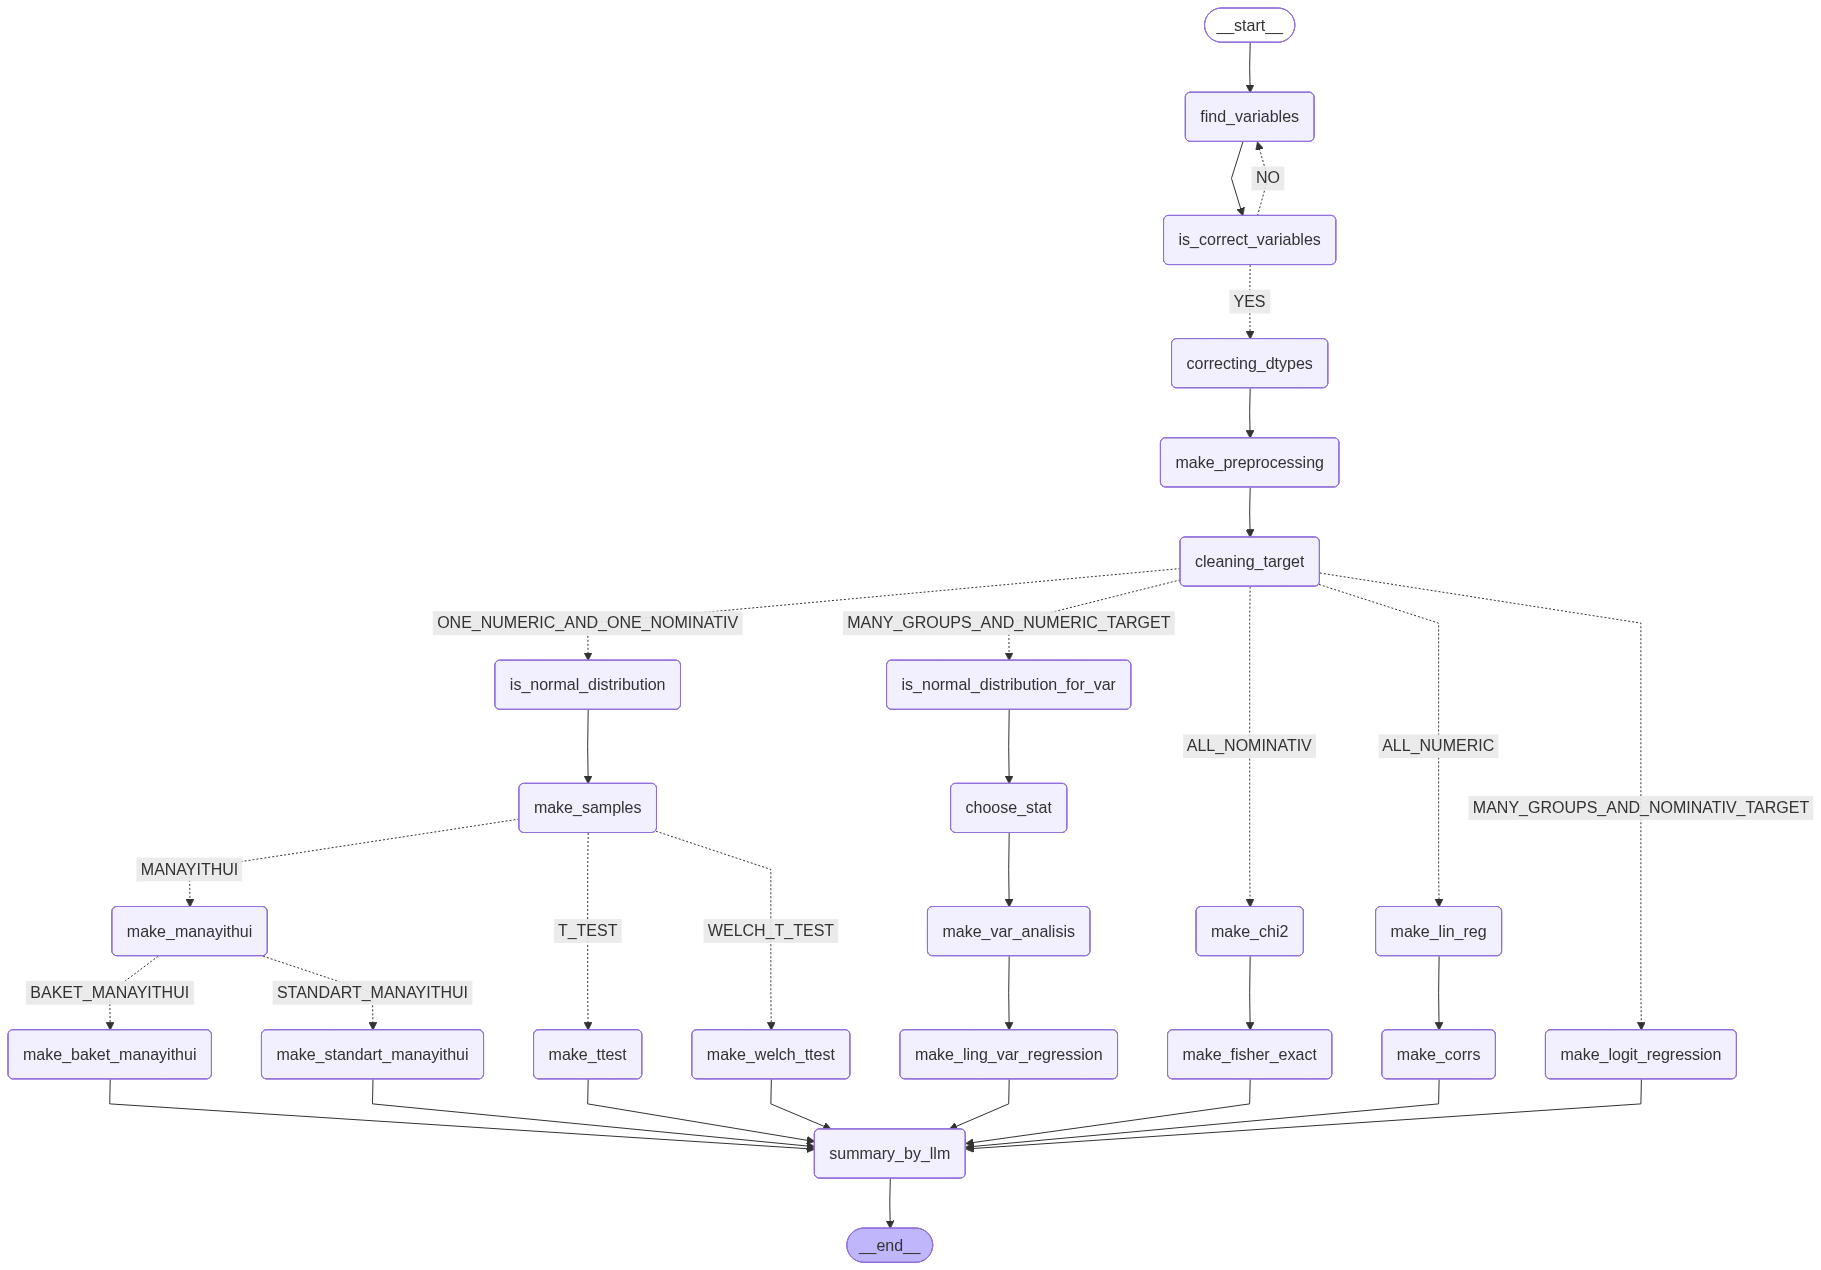

In [47]:
from PIL import Image

Image.open('/content/graph.png')